# Phase 3 (A-B) — System Model Under Uncertainty

After building the dataset (Phase 1) and analyzing forecast errors (Phase 2),
the next step is to build a model of the system that will later be controlled.

The goal of this phase is to define:

- the state of the system
- the inputs we can control
- the disturbances we cannot control
- the constraints of the battery
- how uncertainty affects the system

This phase creates the first battery model that reacts to forecast uncertainty.

### Why Phase 3 is needed

After Phase 2 we know how large forecast errors are,
but we do not yet have a model of the system that will react to them.

Before designing MPC, we must define:

- what the battery state is
- how the battery evolves in time
- what signals the controller sees
- how uncertainty enters the model

Without this step, control design would be undefined.

## Structure

Phase 3 is divided into sub-steps.

Phase 3A — Simple battery model  
Phase 3B — Formal system definition  
Phase 3C (included in phase 4) — Horizon-based control baseline


## Inputs available from Phase 2

From the previous phase we have:

- merged forecasts and actuals
- error statistics
- hourly uncertainty profile

The key file produced in Phase 2:

uncertainty_profile_hourly.csv

For each variable and hour it contains:

- mean_error
- std_error

This will be used to model uncertainty.

## What the system model must include

The battery model must represent:

State
- state of charge (SOC)

Control
- charge power
- discharge power

Disturbance
- load
- solar
- wind onshore
- wind offshore

Uncertainty
- forecast error statistics

Constraints
- power limits
- energy capacity
- efficiency

## First modeling choice

In this first model we do not use optimization.

Instead, we build a simple rule-based response:

- correct forecasts using mean error
- add uncertainty margin using std
- compute risk-adjusted net load
- let battery react to that signal

This gives a first uncertainty-aware system model.

In [7]:
import pandas as pd
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(ROOT, "data", "processed")

df = pd.read_csv(os.path.join(DATA_DIR, "battery_baseline_2025.csv"))

df.head()

,utc_timestamp,hour,load_forecast_mw,solar_forecast_mw,wind_onshore_forecast_mw,wind_offshore_forecast_mw,forecast_net_load_mw,corrected_net_load_mw,reserve_margin_mw,risk_adjusted_net_load_mw,battery_charge_mw,battery_discharge_mw,battery_power_mw,soc_before_mwh,soc_after_mwh,net_load_after_battery_mw
0,2025-01-01 00:00:00+01:00,0,44518.2425,0.0,38472.2225,3759.6575,2286.3625,1257.336958,3617.732264,4875.069222,0.0,25.0,25.0,50.000000,23.684211,1232.336958
1,2025-01-01 01:00:00+01:00,1,42269.3500,0.0,38931.1575,3795.0700,-456.8775,-1480.268030,3641.423966,2161.155936,0.0,22.5,22.5,23.684211,0.000000,-1502.768030
2,2025-01-01 02:00:00+01:00,2,41095.9975,0.0,39388.8900,3826.1900,-2119.0825,-3191.503610,3675.067769,483.564159,0.0,0.0,0.0,0.000000,0.000000,-3191.503610
3,2025-01-01 03:00:00+01:00,3,40805.1225,0.0,39347.5000,3336.8875,-1879.2650,-2946.249059,3674.782901,728.533843,0.0,0.0,0.0,0.000000,0.000000,-2946.249059
4,2025-01-01 04:00:00+01:00,4,40678.0000,0.0,39681.4475,3213.5925,-2217.0400,-3263.283848,3669.210252,405.926404,0.0,0.0,0.0,0.000000,0.000000,-3263.283848


## Battery model output

The model produces for each hour:

Forecast values
- load_forecast_mw
- solar_forecast_mw
- wind_onshore_forecast_mw
- wind_offshore_forecast_mw

Derived values
- forecast_net_load_mw
- corrected_net_load_mw
- reserve_margin_mw
- risk_adjusted_net_load_mw

Battery variables
- battery_charge_mw
- battery_discharge_mw
- battery_power_mw
- soc_before_mwh
- soc_after_mwh

Result
- net_load_after_battery_mw

### SOC evolution

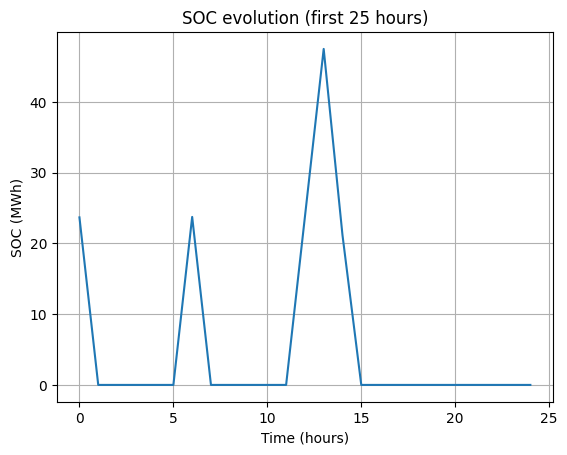

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["soc_after_mwh"][:25])
plt.title("SOC evolution (first 25 hours)")
plt.xlabel("Time (hours)")
plt.ylabel("SOC (MWh)")
plt.grid()
plt.show()


### Battary responce 

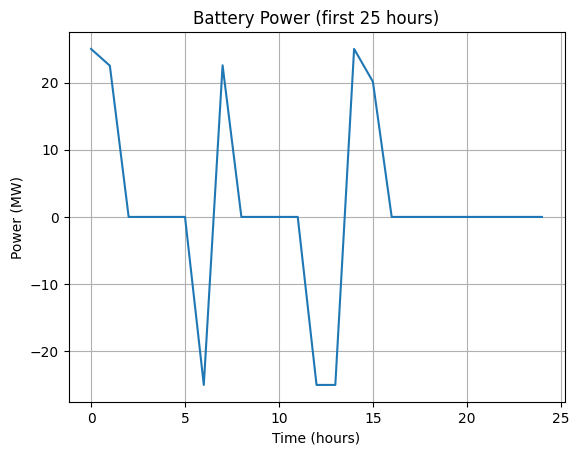

In [9]:
plt.figure()
plt.plot(df["battery_power_mw"][:25])
plt.title("Battery Power (first 25 hours)")
plt.xlabel("Time (hours)")
plt.ylabel("Power (MW)")
plt.grid()
plt.show()

## How Uncertainty enters the model

Uncertainty is taken from the hourly profile. 

For each hour: 

* mean_error --> correct forecast
* std_error --> build reserve margin 

Reserve margin is added to the to the corrected net load, creating a risk adjusted signal that the battary reacts to 


## Limitations of the simple model

This model is intentionally simple.

Limitations:

- no price signal
- no optimization
- no horizon
- reserve margin is very conservative
- battery reacts greedily

These limitations motivate the next steps of Phase 3.


## Conclusion

Phase 3A produced the first system model that reacts to uncertainty.

The battery now has:

- state dynamics
- constraints
- uncertainty input

This model will be refined before designing MPC.

## Phase 3B — Formal system definition

The simple battery model shows how the system behaves,
but for control design we need a formal description.

We must define:

- state
- control input
- disturbance
- system dynamics
- constraints

This representation will later be used for MPC.

### State variable

The system state is the battery state of charge:

SOC_t

Units:
MWh

SOC changes over time depending on charge and discharge.

SOC is limited by battery capacity.

### Control input

The control variable is the battery power:

P_t

Positive → discharge  
Negative → charge

Limits:

|P_t| ≤ P_max

### Disturbances

The controller cannot control load or renewable generation.

Disturbances:

- load
- solar
- wind_onshore
- wind_offshore

These values are uncertain and come from forecasts.

Forecast error statistics from Phase 2 are used to model uncertainty.

### Net load

Net load is defined as:

net_load = load − solar − wind_onshore − wind_offshore

This represents the demand that must be covered
by dispatchable generation or the battery.

### Uncertainty model

For each hour we have:

mean_error(hour)
std_error(hour)

Corrected value:

corrected = forecast + mean_error

Reserve margin:

margin = std_error

Risk-adjusted net load:

net_load_risk = corrected_net_load + margin

### State equation

Battery dynamics:

SOC_{t+1} =
SOC_t
+ η_charge * P_charge * Δt
− (P_discharge * Δt) / η_discharge

Constraints:

0 ≤ SOC ≤ E_max

### Power limits

Battery power is limited:

|P_t| ≤ P_max

Charge and discharge cannot exceed power capacity.

### Energy limits

Battery energy must stay inside bounds:

0 ≤ SOC_t ≤ E_max

This constraint makes the system nonlinear
because future decisions depend on current SOC.

## Why the simple rule is not enough

In Phase 3A the battery reacts only to the current hour.

This is greedy control.

Problems:

- battery may empty too early
- battery may charge when it should wait
- future uncertainty is ignored

To solve this, the controller must look ahead.

This leads to Model Predictive Control.

## Control horizon

Instead of deciding only for the current hour,
we consider multiple future hours.

At each step we solve:

minimize cost over horizon

subject to

- dynamics
- constraints
- uncertainty

This is the idea of MPC.

## Phase 3 summary

Phase 3A
- simple battery simulation

Phase 3B
- formal system definition

The system now has:

state
control
disturbance
constraints
uncertainty

This is enough to build MPC.

## Transition to Phase 4

Phase 4 will implement MPC.

We will define:

- objective function
- horizon
- optimization problem
- constraints

The model defined in Phase 3B will be used as the system.